In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

from scipy.signal import find_peaks

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


In [2]:

def load_file_one_go(files, chunk_size, baseline_window_ns, channel):
    prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin='zero',
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]

    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in ['is_saturated', 'n_saturated_samples']}
    preprocessed_event_info.update({ 
        'event_file': prerocessed_data['event_file'],
        'event_segment': prerocessed_data['event_segment']
    })

    df = build_waveform_feature_dataframe(
        time_ns,
        voltage_mV,
        peak_threshold_mV=None,
        second_peak_min_height_frac=0.2,
        pre_peak_ns = 20,
        post_peak_ns = 80,
        pre_rise_ns = 10, 
        post_rise_ns = 80, 
        extra=preprocessed_event_info 
    )
    cutflow = CutFlow(len(df))

    cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
    cutflow.print()

    df_sel = df[cutflow.mask].copy()
    waveforms_sel = voltage_mV[cutflow.mask]

    return time_ns, waveforms_sel, df_sel


# Select Files


In [3]:
channel="Channel 4"
data_dir = Path("data/WA0089/voltage_sweep/260705")

# file_name = "WA0089_500V_525MHz_led000"
# file_name = "WA0089_500V_525MHz_led100"
# file_name = "WA0089_550V_525MHz_led000"
# file_name = "WA0089_550V_525MHz_led100"
# file_name = "WA0089_600V_525MHz_led000"
# file_name = "WA0089_600V_525MHz_led100"
# file_name = "WA0089_650V_525MHz_led100"
# file_name = "WA0089_700V_525MHz_led100"

# file_name = "WA0089_750V_525MHz_led100" ## REDO
# file_name = "WA0089_800V_525MHz_led100" ## REDO

# file_name = "WA0089_850V_525MHz_led100"
# file_name = "WA0089_875V_525MHz_led100"


file_name = "WA0089_900V_525MHz_led100"
# file_name = "WA0089_925V_525MHz_led100"
# file_name = "WA0089_950V_525MHz_led100"
# file_name = "WA0089_975V_525MHz_led100"
# file_name = "WA0089_1000V_525MHz_led100"

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")

# save
save_plots = True
save_dir = 'plots/260705'
file_nickname = file_name

data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-10.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-3.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-4.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-5.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-6.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-7.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-8.h5
data/WA0089/voltage_sweep/260705/WA0089_900V_525MHz_led100-9.h5
Number of files loaded: 8


In [4]:
chunk_size = 512 #4096
# baseline_window_width_ns          = 20
baseline_window_ns                = (0, 20)
selection_peak_threshold_max_mV   = 0.5

In [5]:
# files = [
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-1.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-10.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-2.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-3.h5",
#     # "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-4.h5", ## NO
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-5.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-6.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-7.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-8.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_750V_525MHz_led100-9.h5"
# ]

# files = [
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-1.h5",
#     # "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-10.h5", ## NO
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-2.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-3.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-4.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-5.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-6.h5",
#     "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-7.h5"
#     # "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-8.h5" ## NO
#     # "data/WA0089/voltage_sweep/260705/WA0089_800V_525MHz_led100-9.h5" ## NO
# ]

time_ns, waveforms_mV, df =  load_file_one_go(files, chunk_size, baseline_window_ns, channel)


OSError: Unable to synchronously open file (file signature not found)

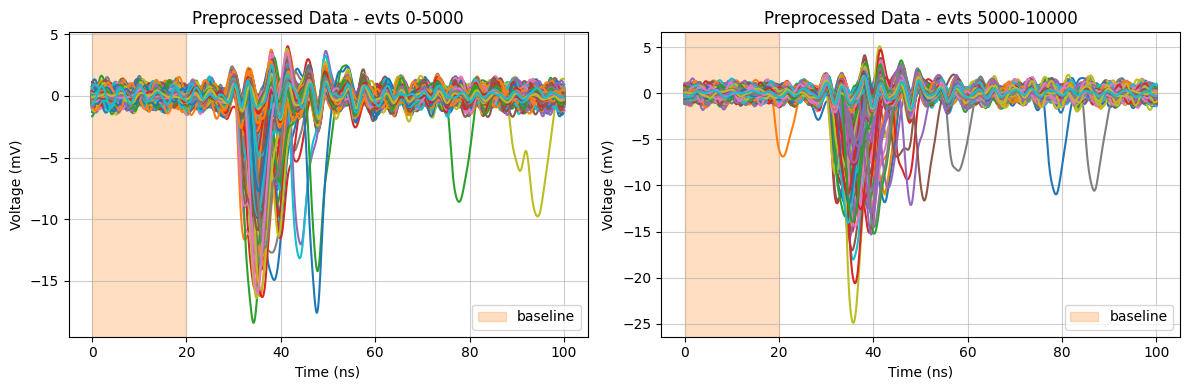

In [ ]:
n_to_plot = 5000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, waveforms_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, waveforms_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

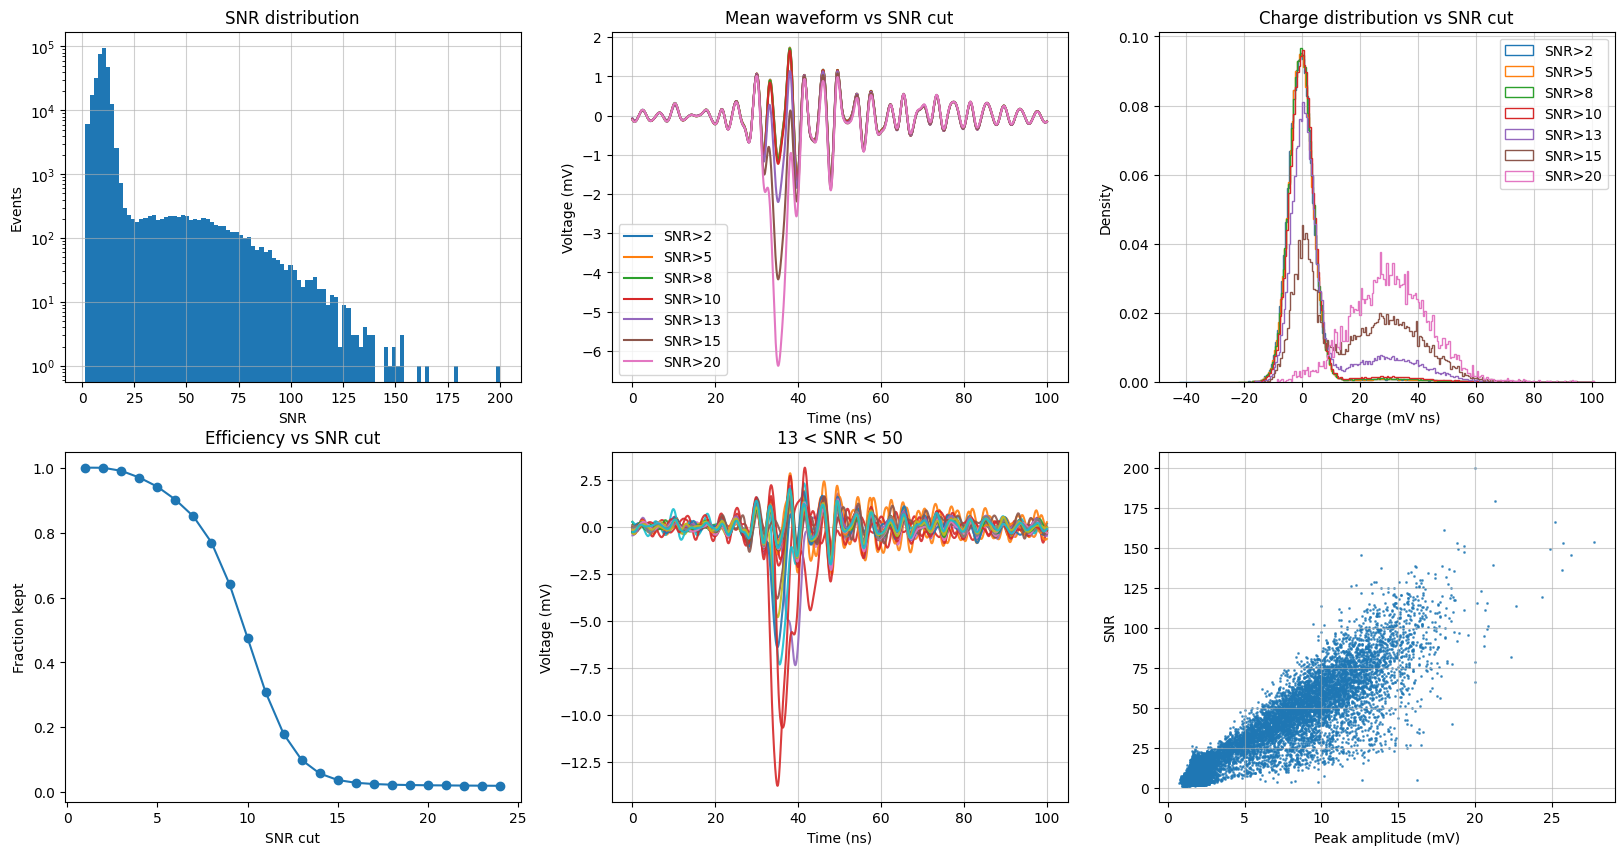

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df)
plot_mean_waveforms_vs_snr(axes[1], df, waveforms_mV, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df, waveforms_mV, time_ns, snr_min=13, snr_max=50, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df)  
save_plot(fig, save_plots, save_dir, file_nickname, f"snr_repport",  Nevents=None);

[PosixPath('plots/260705/WA0089_850V_525MHz_led100_charge_all_methods.pdf')]

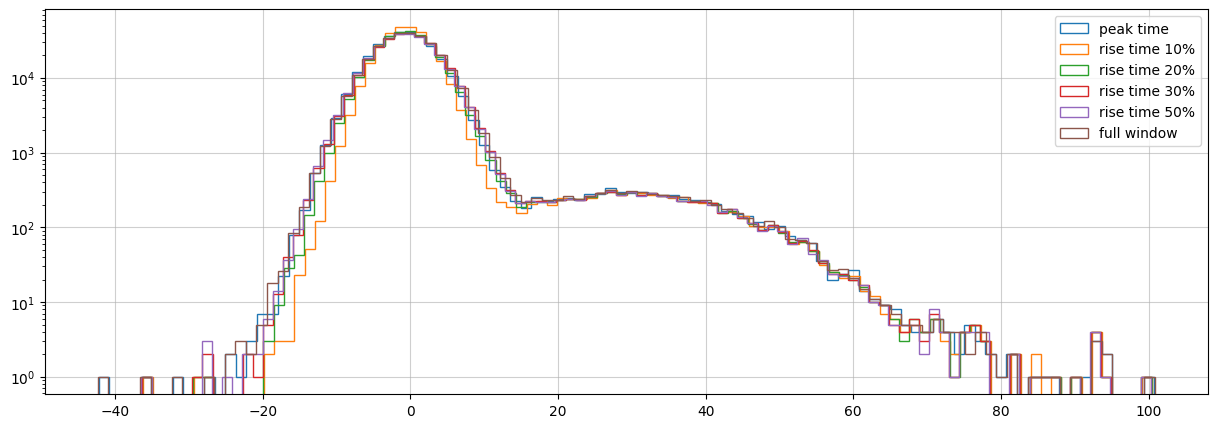

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None)



# Baseline Study

In [ ]:
from scipy import stats
from scipy.stats import norm
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.signal import welch

In [ ]:
t, wfs, df = time_ns, waveforms_mV, df

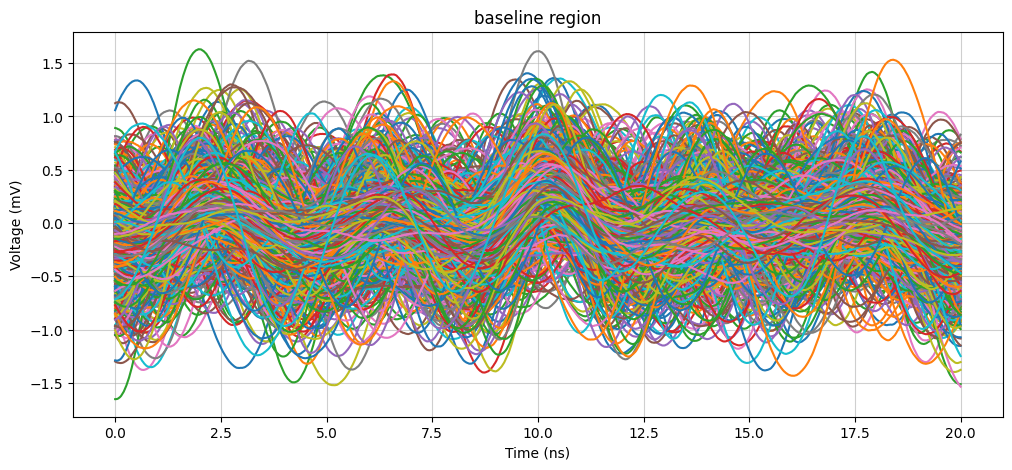

In [ ]:
mask = (t >= baseline_window_ns[0]) & (t <= baseline_window_ns[1])
baseline_region = wfs[:, mask]
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
add_plot_waveforms(axes, t[mask], baseline_region[:5000], title='baseline region')
save_plot(fig, save_plots, save_dir, file_nickname, f"Baseline",  Nevents=5000);

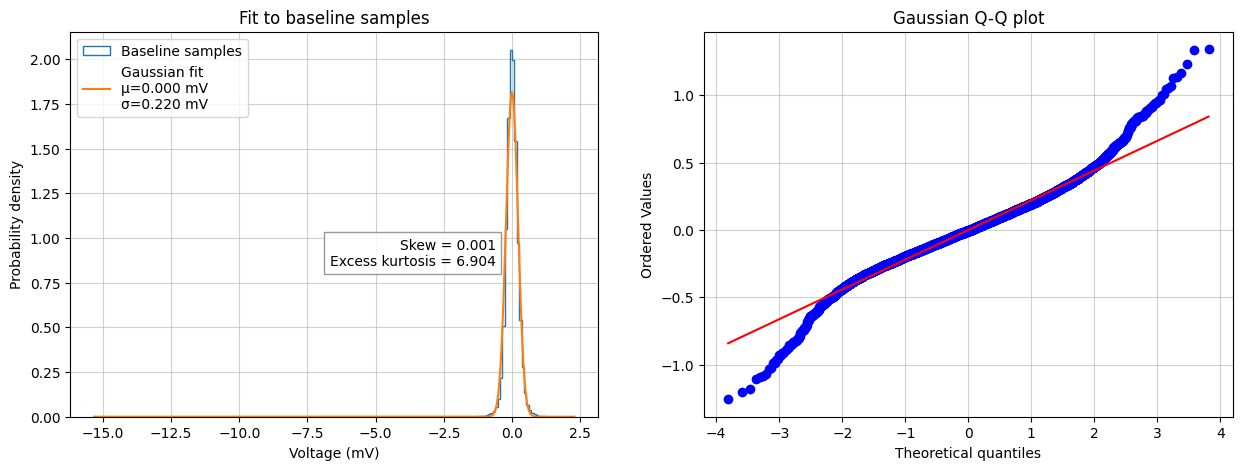

In [ ]:
samples = baseline_region.ravel()
mu, sigma = norm.fit(samples)
sk = skew(samples)
kurt = kurtosis(samples)

stats_text = ( f"Skew = {sk:.3f}\n" f"Excess kurtosis = {kurt:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

x = np.linspace(samples.min(), samples.max(), 500)
axes[0].hist(samples, bins=200, density=True, histtype='step', label='Baseline samples')
axes[0].plot(x, norm.pdf(x, mu, sigma), label=f'Gaussian fit\nμ={mu:.3f} mV\nσ={sigma:.3f} mV')
axes[0].text( -0.6, 1.0, stats_text, ha='right', va='top',
          bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray') )
axes[0].set_xlabel("Voltage (mV)")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Fit to baseline samples")
axes[0].legend();

rng = np.random.default_rng(42)
idx = rng.choice(len(samples), size=10_000, replace=False)
stats.probplot(samples[idx], dist="norm", plot=plt)
axes[1].set_title("Gaussian Q-Q plot")
save_plot(fig, save_plots, save_dir, file_nickname, f"baseline_fit",  Nevents=None);





Sampling step: 0.01562 ns


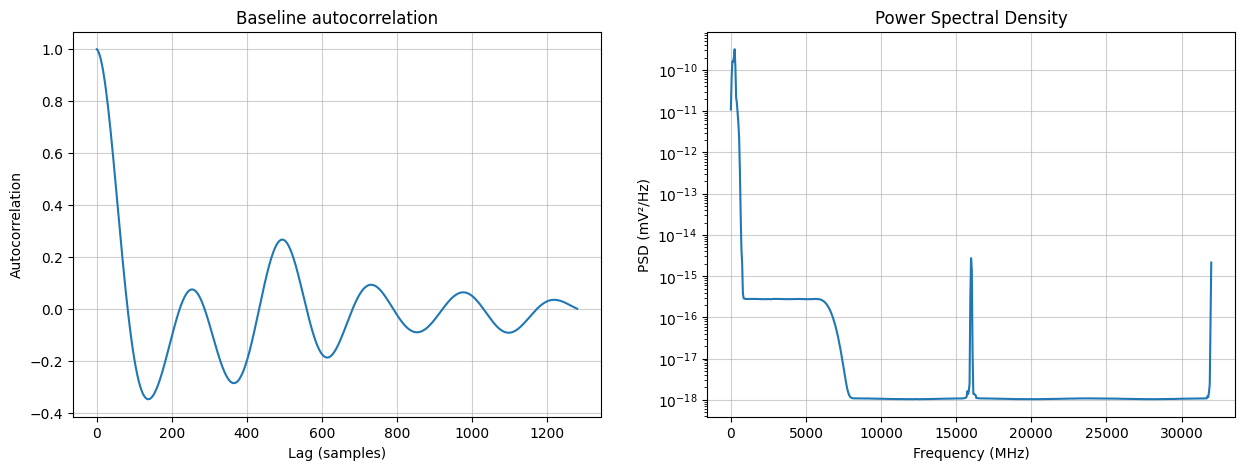

In [ ]:
corr = np.zeros(baseline_region.shape[1])
for wf in baseline_region:
    c = correlate(wf, wf, mode='full')
    c = c[c.size//2:]
    corr += c / c[0]          # normalize
corr /= len(baseline_region)
lags = np.arange(len(corr))


dt = np.median(np.diff(t))
print(f"Sampling step: {dt:.5f} ns")
fs = 1 / (dt * 1e-9)          # sampling frequency (Hz)
psds = []
for wf in baseline_region:
    f, Pxx = welch( wf, fs=fs, nperseg=len(wf), detrend='constant')
    psds.append(Pxx)
psd = np.mean(psds, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

axes[0].plot(lags, corr)
axes[0].set_title("Baseline autocorrelation")
axes[0].set_xlabel("Lag (samples)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True);

axes[1].semilogy(f/1e6, psd)
axes[1].set_title("Power Spectral Density")
axes[1].set_xlabel("Frequency (MHz)")
axes[1].set_ylabel("PSD (mV²/Hz)")
axes[1].grid(True)

save_plot(fig, save_plots, save_dir, file_nickname, f"autocorrelation",  Nevents=None);

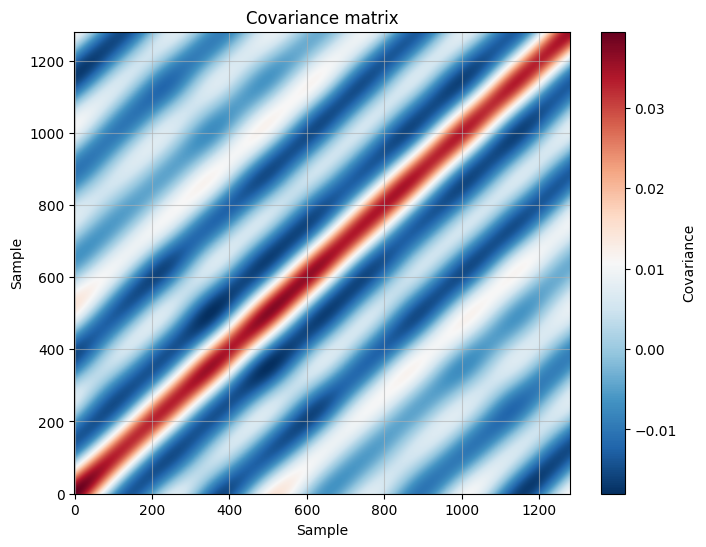

In [ ]:
C = np.cov(baseline_region.T)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))

plt.imshow(C,
           origin='lower',
           cmap='RdBu_r',
           aspect='auto')
plt.colorbar(label="Covariance")
plt.title("Covariance matrix")
plt.xlabel("Sample")
plt.ylabel("Sample")

save_plot(fig, save_plots, save_dir, file_nickname, f"covariance_matrix",  Nevents=None);